In [4]:
import pandas as pd
from scipy.optimize import curve_fit
import numpy as np
import json
from matplotlib import pyplot as plt
from scipy.integrate import odeint

# load the data
data = pd.read_csv('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/data_covid-19_EU.csv')

# convert dates and filter by country
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data_country = data[data['countriesAndTerritories'] == 'Austria'].sort_values('dateRep')

# Calculate accumulated
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0)

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
data_country['infected'] = data_country['cum_cases'] - data_country['cum_deaths'] - data_country['recovered']
data_country['susceptible'] = N - data_country['infected'] - data_country['recovered']

# Derivatives
data_country['dI'] = data_country['infected'].diff().fillna(0)
data_country['dR'] = data_country['recovered'].diff().fillna(0)

# Data for adjustment
I = data_country['infected'].values
S = data_country['susceptible'].values
dI = data_country['dI'].values
t = np.arange(len(data_country))

# Fitting model
def fit_sir(t, beta, gamma):
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    return dIdt

# beta and gamma
popt, _ = curve_fit(fit_sir, t, dI, p0=[0.2, 0.1], maxfev=10000)
beta, gamma = popt

# Save beta and gamma in a JSON file
params = {'beta': beta, 'gamma': gamma}
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'w') as file:
    json.dump(params, file)

print("Infection rate (beta):", beta)
print("Recovery rate (gamma):", gamma)
print("Parameters saved in params.json")


Infection rate (beta): 0.11560646585444855
Recovery rate (gamma): 0.07575845874573703
Parameters saved in params.json


In [5]:
# Obtain the list of unique countries
countries = data['countriesAndTerritories'].unique()

# Count the number of countries and display the list
num_countries = len(countries)
countries_list = sorted(countries)

print(f"Total countries: {num_countries}")
print("List of countries:")
for country in countries_list:
    print(country)


Total countries: 30
List of countries:
Austria
Belgium
Bulgaria
Croatia
Cyprus
Czechia
Denmark
Estonia
Finland
France
Germany
Greece
Hungary
Iceland
Ireland
Italy
Latvia
Liechtenstein
Lithuania
Luxembourg
Malta
Netherlands
Norway
Poland
Portugal
Romania
Slovakia
Slovenia
Spain
Sweden


In [6]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Austria'][['cases', 'deaths', 'popData2020']].head())

     cases  deaths  popData2020
0   3557.0     0.0      8901064
1   5494.0     4.0      8901064
2   7776.0     4.0      8901064
3   8221.0     6.0      8901064
4  10007.0     8.0      8901064


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Austria.png


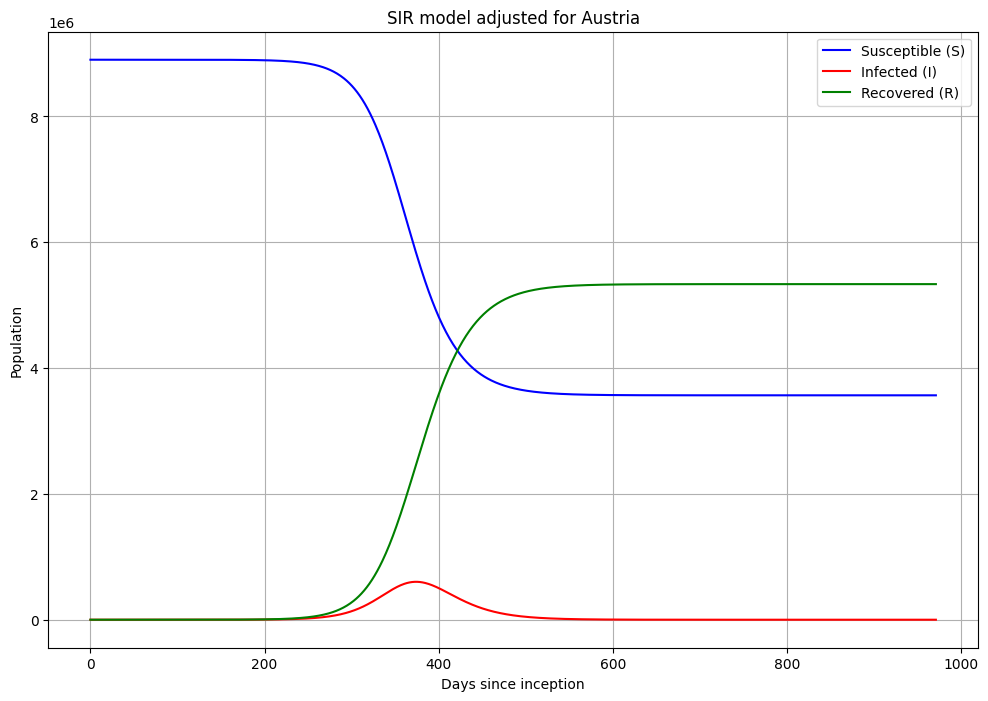

In [62]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Austria'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [64]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Bulgaria'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
2900    4.0     0.0      6951482
2899    0.0     0.0      6951482
2898    0.0     1.0      6951482
2897    2.0     NaN      6951482
2896    1.0     NaN      6951482


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Bulgaria.png


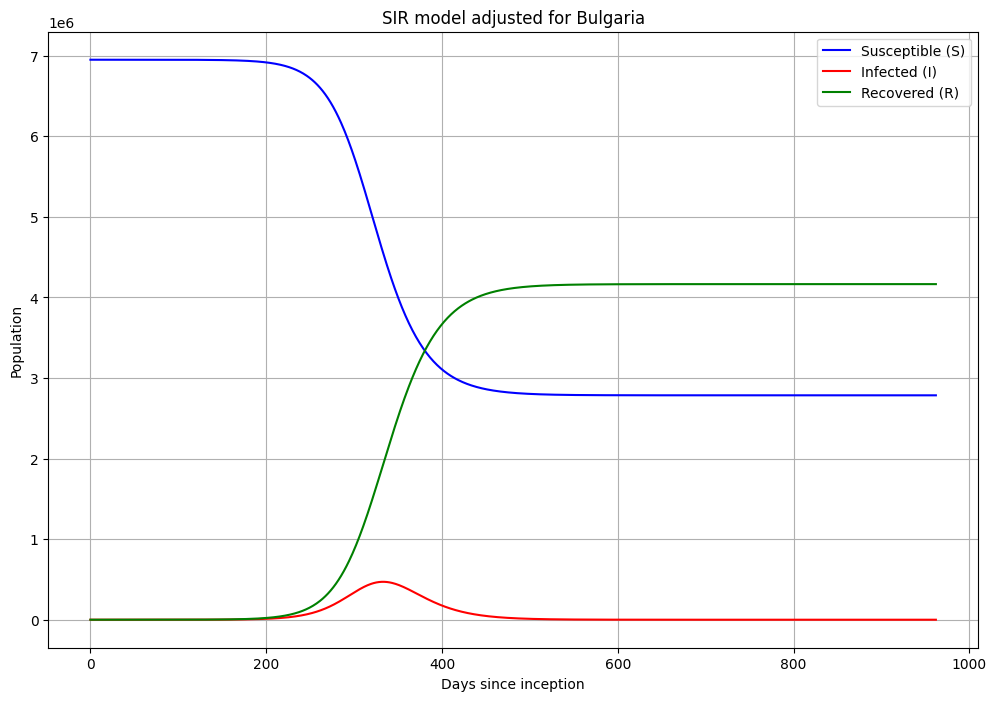

In [65]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Bulgaria'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [33]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Croatia'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
3872    2.0     0.0      4058165
3871    1.0     0.0      4058165
3870    0.0     0.0      4058165
3869    2.0     0.0      4058165
3868    2.0     0.0      4058165


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Croatia.png


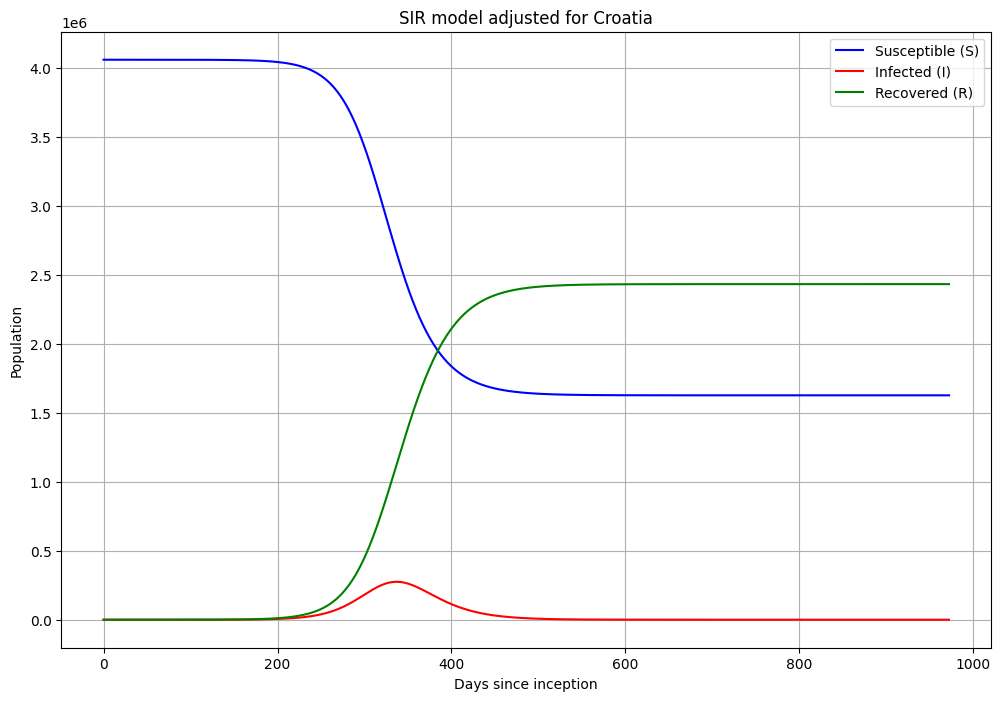

In [67]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Croatia'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [34]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Cyprus'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
4666    2.0     0.0       888005
4665    1.0     0.0       888005
4664    3.0     0.0       888005
4663    0.0     0.0       888005
4662    8.0     0.0       888005


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Cyprus.png


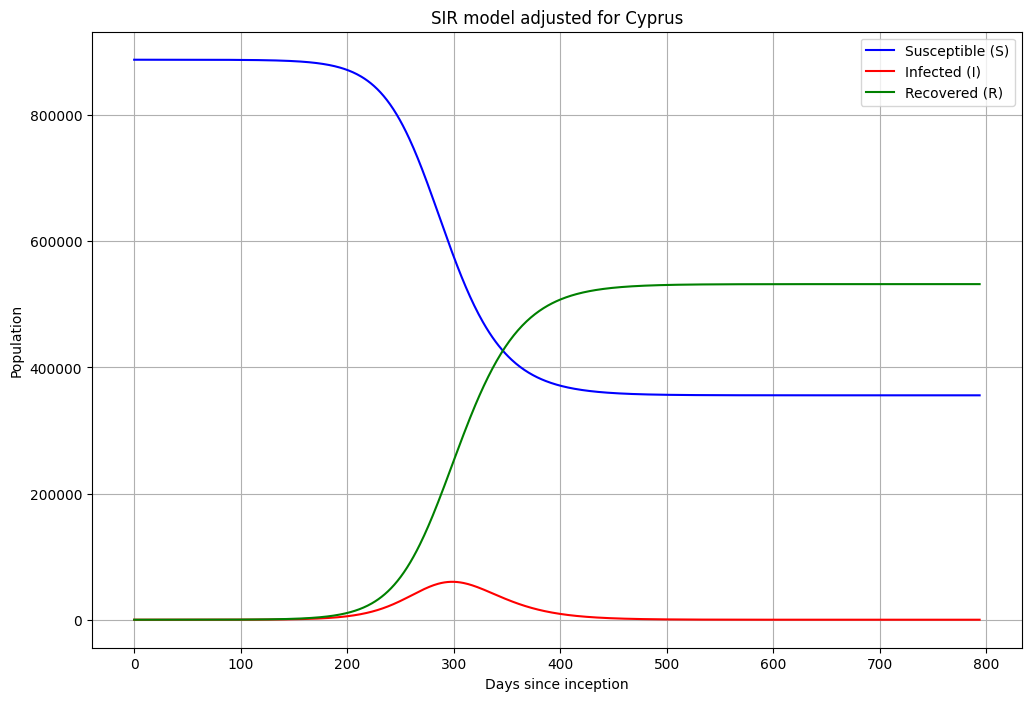

In [68]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Cyprus'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [69]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Denmark'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
6600    1.0     0.0      5822763
6599    1.0     0.0      5822763
6598    1.0     0.0      5822763
6597    1.0     0.0      5822763
6596    4.0     0.0      5822763


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Denmark.png


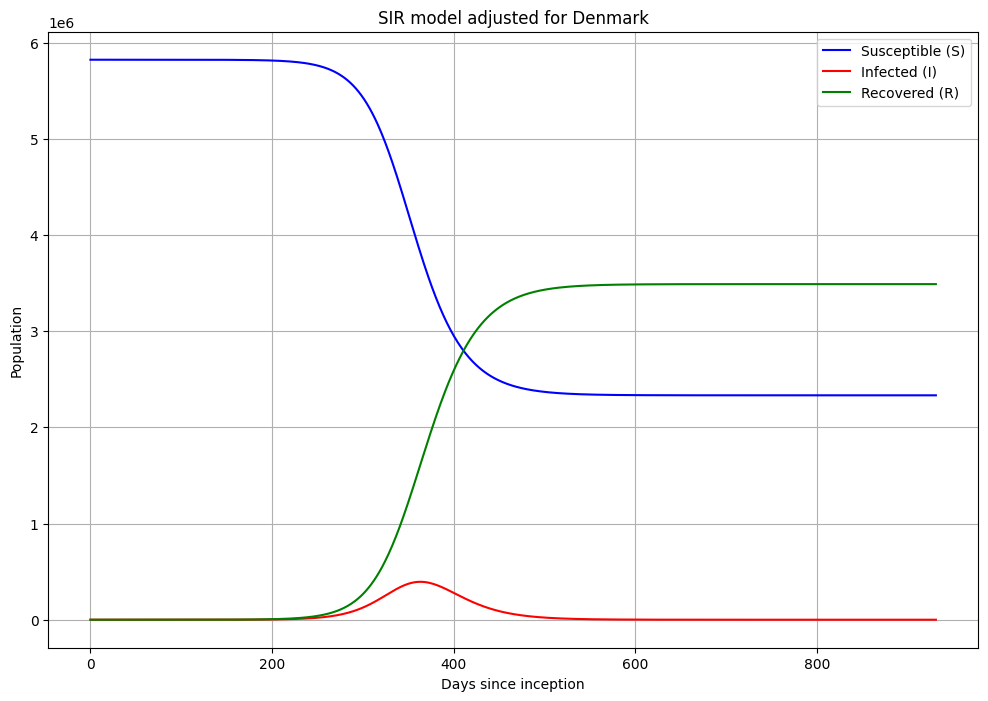

In [71]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Denmark'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [72]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Estonia'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
7573    1.0     0.0      1328976
7572    0.0     0.0      1328976
7571    0.0     0.0      1328976
7570    0.0     0.0      1328976
7569    0.0     0.0      1328976


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Estonia.png


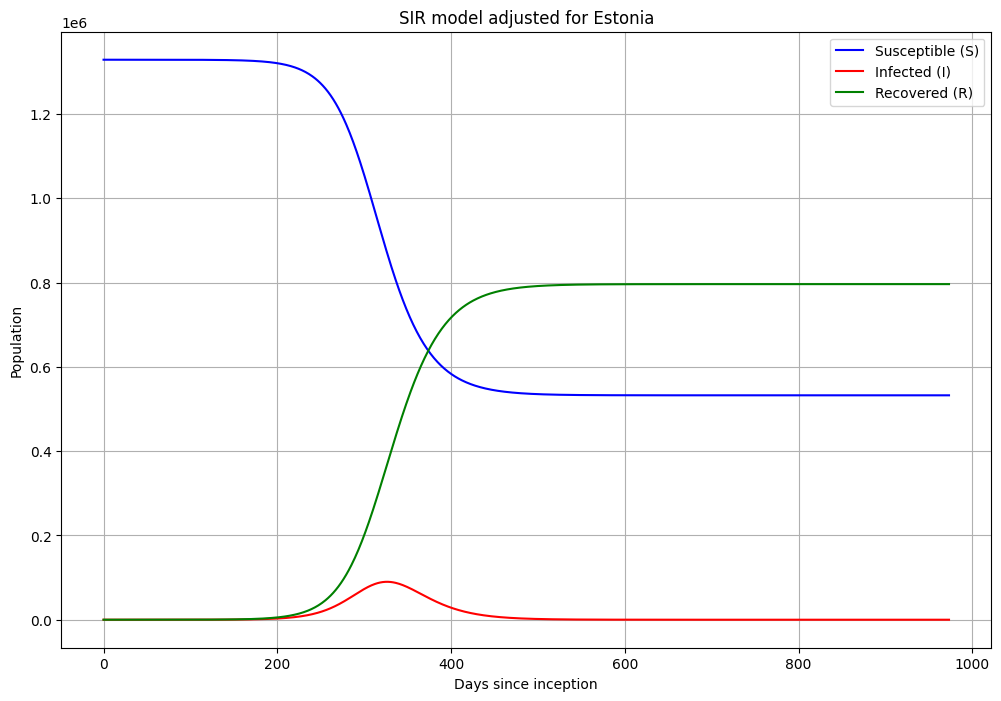

In [74]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Estonia'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [75]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Finland'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
8597    1.0     0.0      5525292
8596    0.0     0.0      5525292
8595    0.0     0.0      5525292
8594    0.0     0.0      5525292
8593    0.0     0.0      5525292


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Finland.png


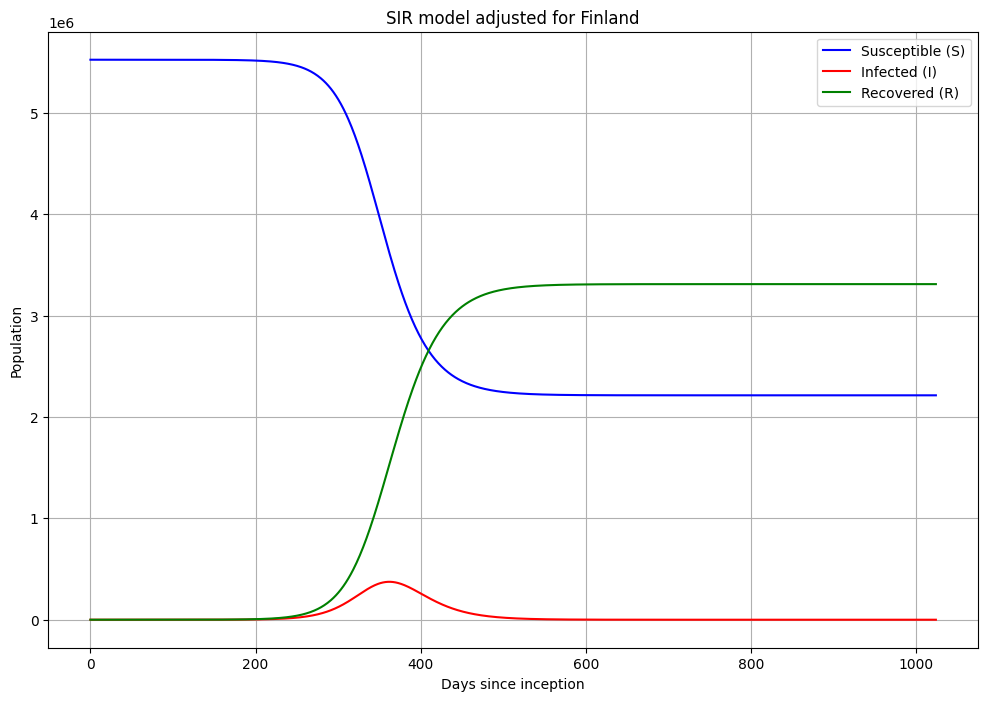

In [76]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Finland'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [103]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'France'][['cases', 'deaths', 'popData2020']].head())

      cases  deaths  popData2020
9603    1.0     0.0     67320216
9602    2.0     0.0     67320216
9601    0.0     0.0     67320216
9600    0.0     0.0     67320216
9599   -3.0     0.0     67320216


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_France.png


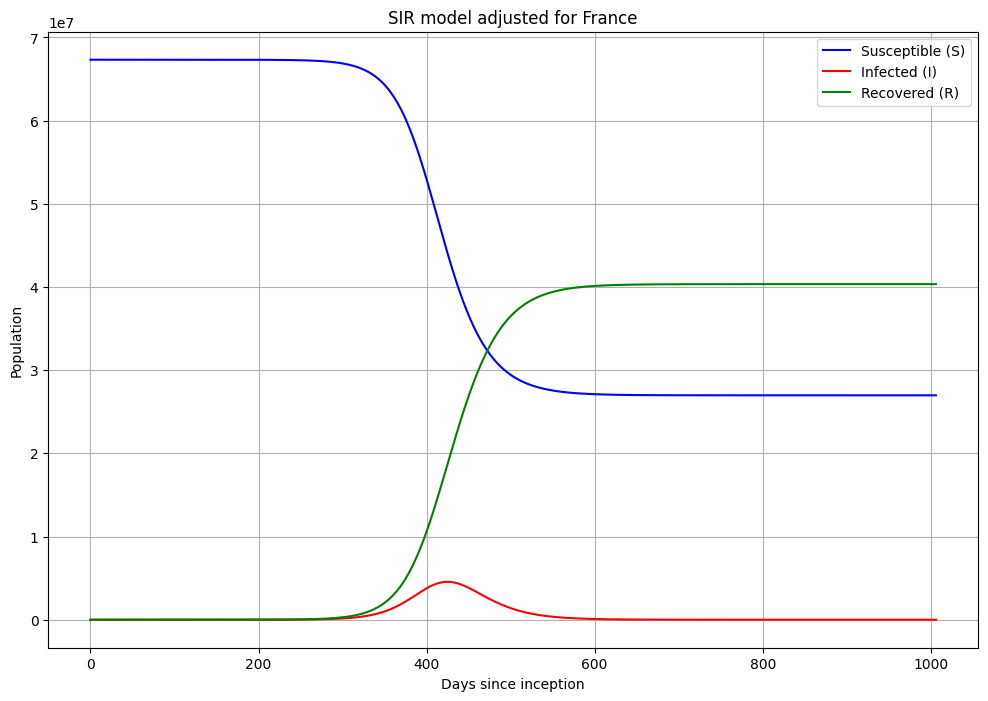

In [77]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'France'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [78]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Germany'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
10595    1.0     0.0     83166711
10594    1.0     0.0     83166711
10593    2.0     0.0     83166711
10592    2.0     0.0     83166711
10591    4.0     0.0     83166711


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Germany.png


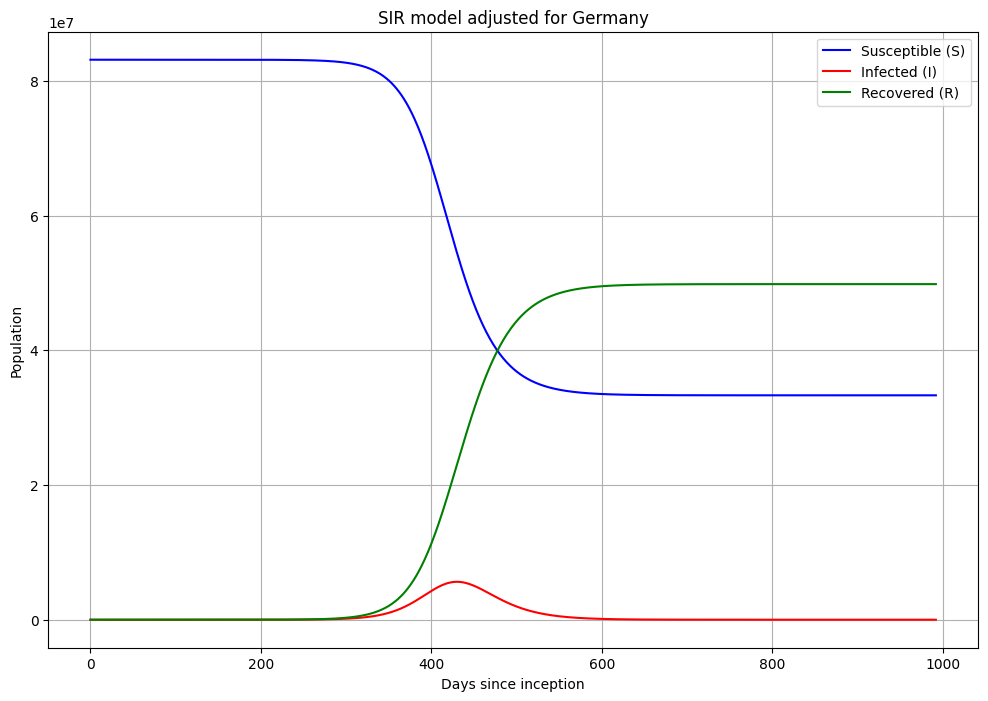

In [79]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Germany'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [80]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Greece'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
11566    1.0     0.0     10718565
11565    2.0     0.0     10718565
11564    1.0     0.0     10718565
11563    1.0     0.0     10718565
11562    2.0     0.0     10718565


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Greece.png


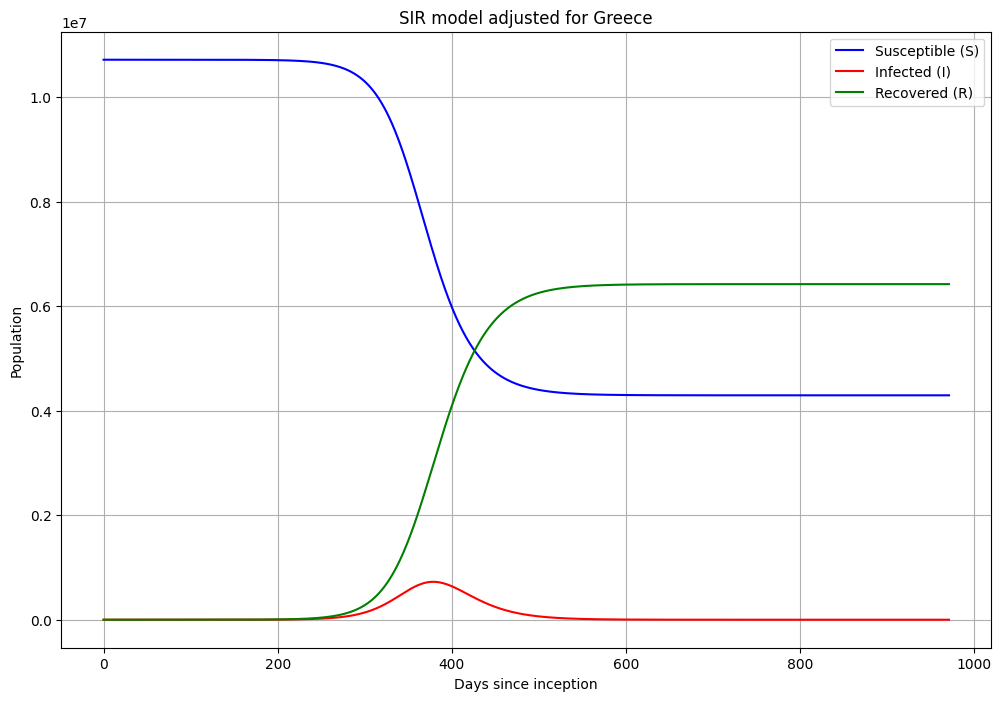

In [81]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Greece'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [45]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Hungary'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
12534    0.0     0.0      9769526
12533    2.0     0.0      9769526
12532    2.0     0.0      9769526
12531    0.0     0.0      9769526
12530    1.0     0.0      9769526


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Hungary.png


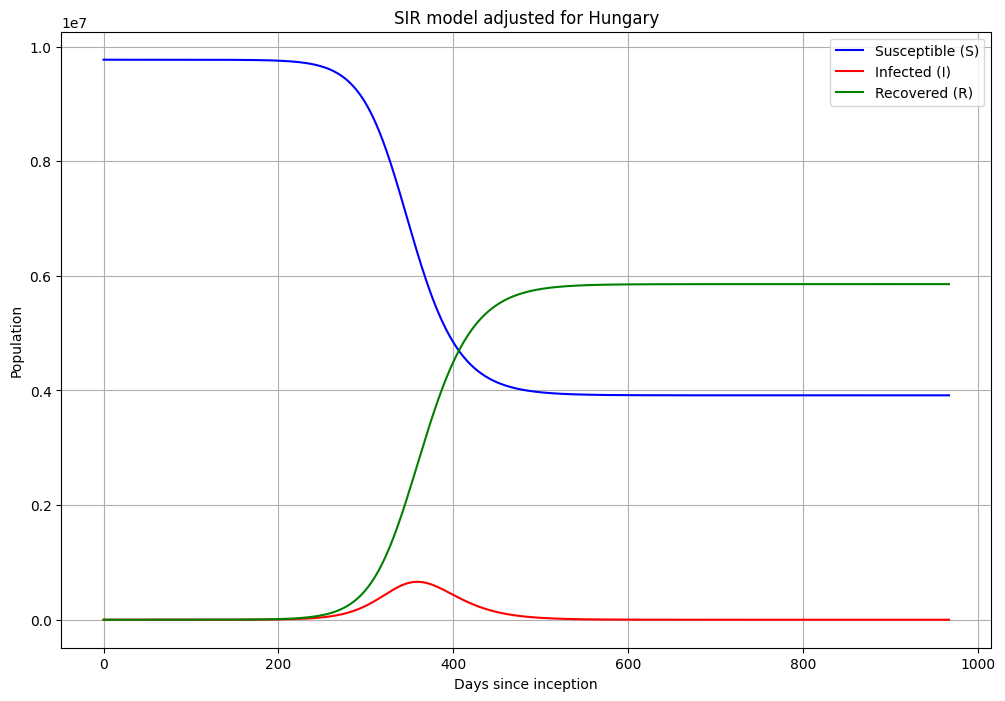

Initial Infected: 2.0


In [ ]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Hungary'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Exclude the first row
data_country = data_country.iloc[1:].reset_index(drop=True)

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [48]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Ireland'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
14299    1.0     0.0      4964440
14298    0.0     0.0      4964440
14297    1.0     0.0      4964440
14296    4.0     0.0      4964440
14295    7.0     0.0      4964440


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Ireland.png


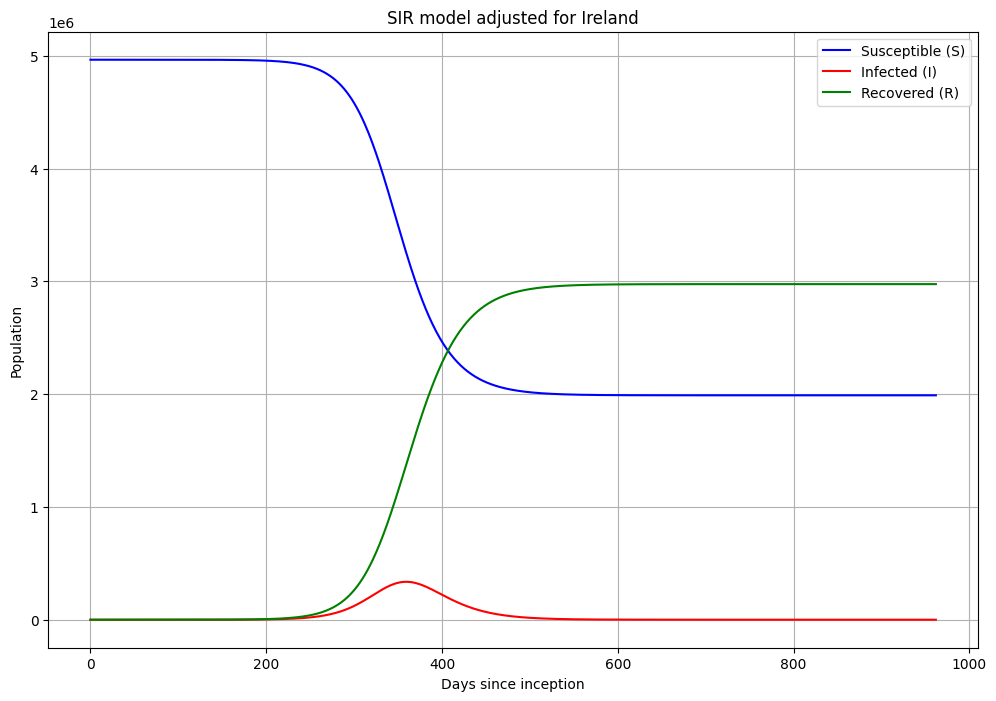

In [85]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Ireland'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [86]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Italy'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
15273  229.0     7.0     59641488
15272   93.0     3.0     59641488
15271   78.0     2.0     59641488
15270  250.0     5.0     59641488
15269  238.0     4.0     59641488


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Italy.png


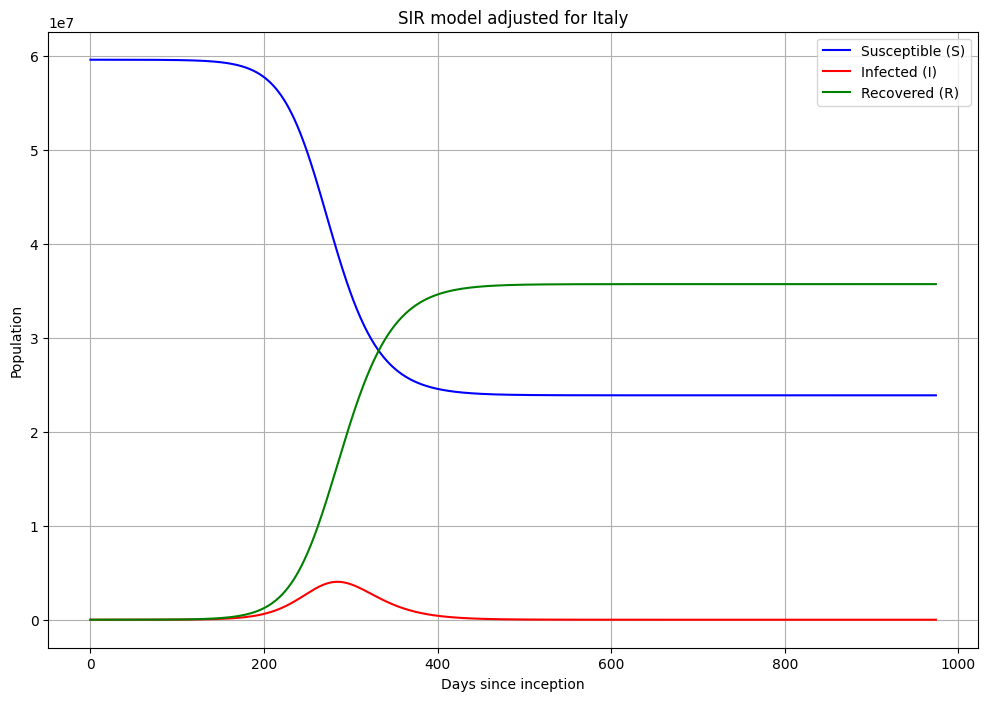

In [87]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Italy'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [52]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Latvia'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
16243    0.0     0.0      1907675
16242    0.0     0.0      1907675
16241    0.0     0.0      1907675
16240    1.0     0.0      1907675
16239    0.0     0.0      1907675


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Latvia.png


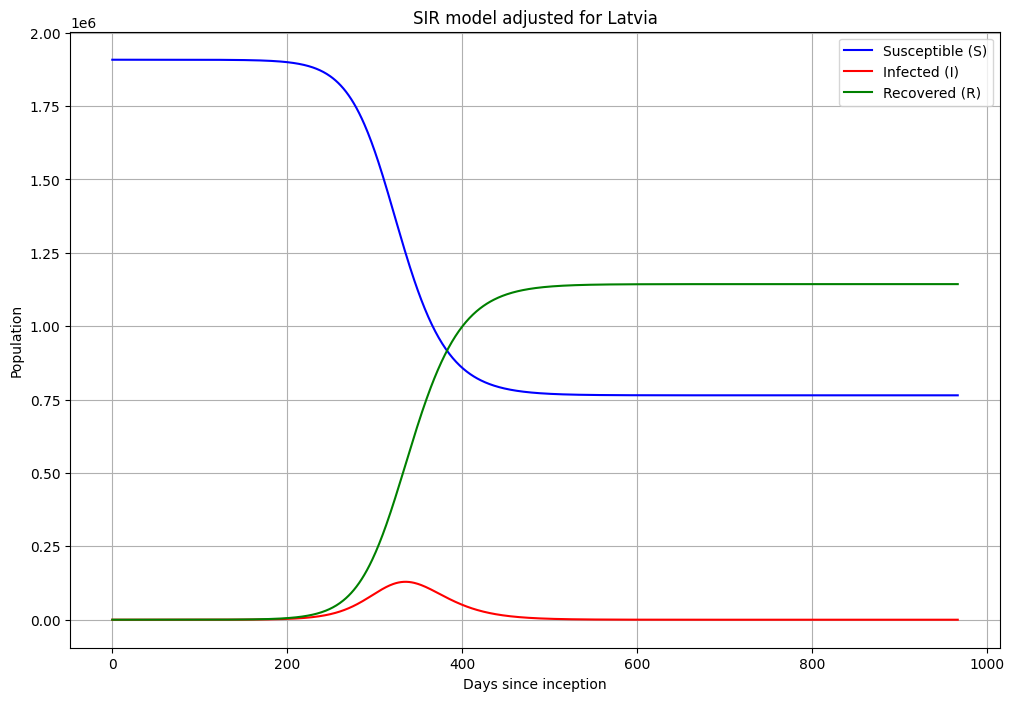

In [89]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Latvia'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Exclude the first row
data_country = data_country.iloc[3:].reset_index(drop=True)

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [90]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Liechtenstein'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
17191    0.0     0.0        38747
17190    0.0     0.0        38747
17189    1.0     0.0        38747
17188    0.0     0.0        38747
17187    0.0     0.0        38747


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Liechtenstein.png


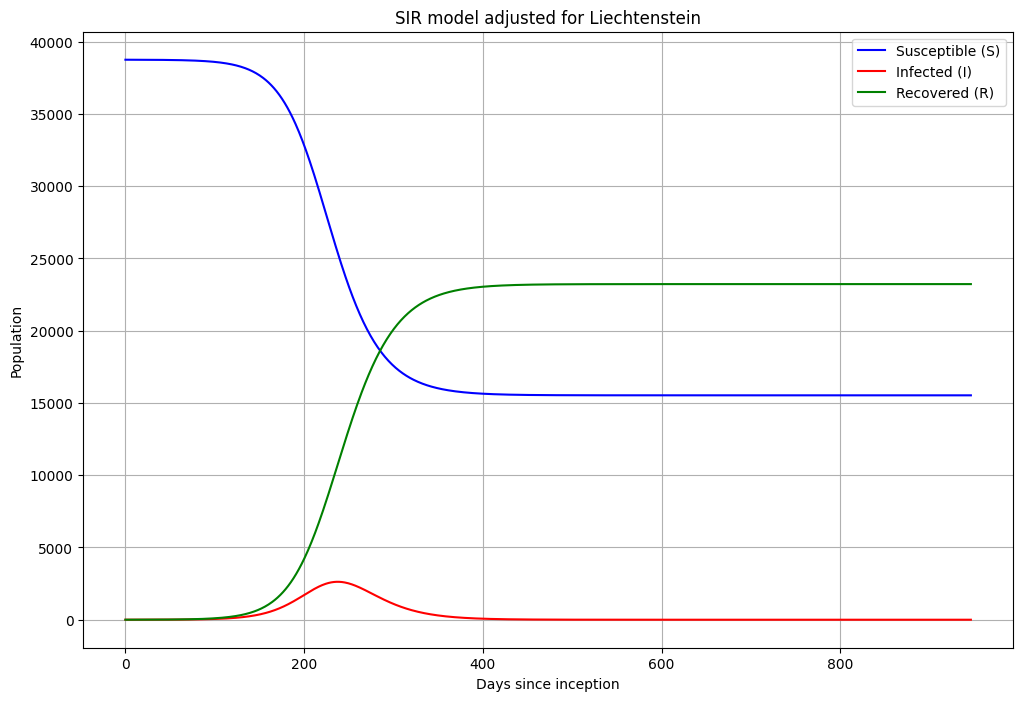

In [92]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Liechtenstein'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Exclude the first row
data_country = data_country.iloc[2:].reset_index(drop=True)

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [93]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Luxembourg'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
19161    0.0     0.0       626108
19160    0.0     0.0       626108
19159    0.0     0.0       626108
19158    0.0     0.0       626108
19157    0.0     0.0       626108


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Latvia.png


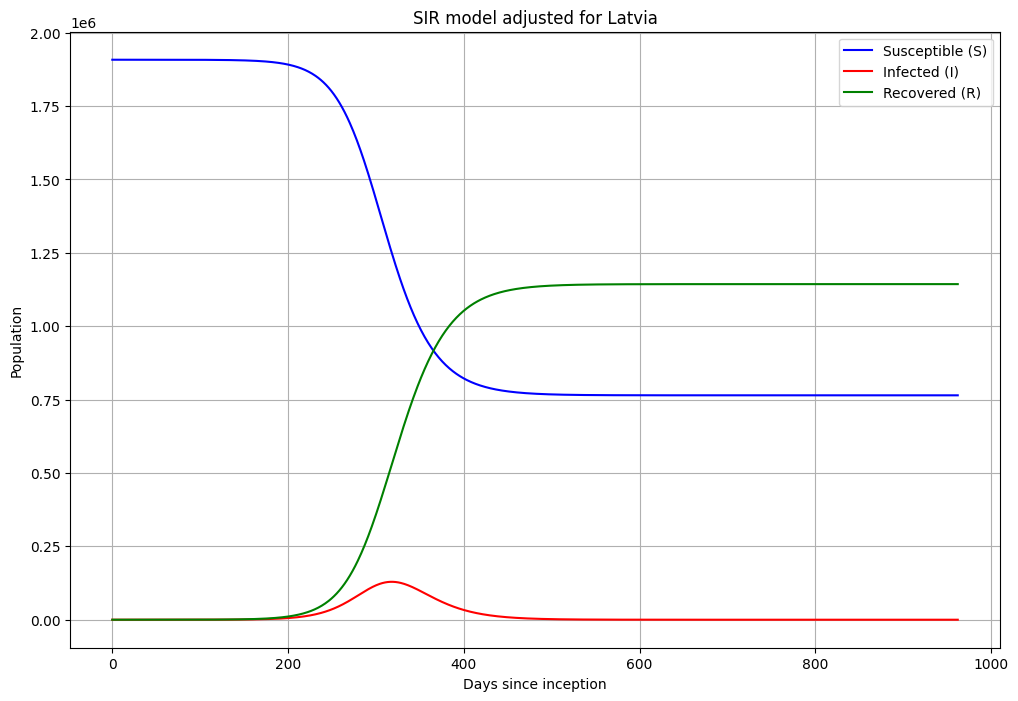

In [97]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Latvia'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Exclude the first row
data_country = data_country.iloc[8:].reset_index(drop=True)

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [98]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Malta'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
20125    1.0     0.0       514564
20124    2.0     0.0       514564
20123    0.0     0.0       514564
20122    1.0     0.0       514564
20121    1.0     0.0       514564


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Malta.png


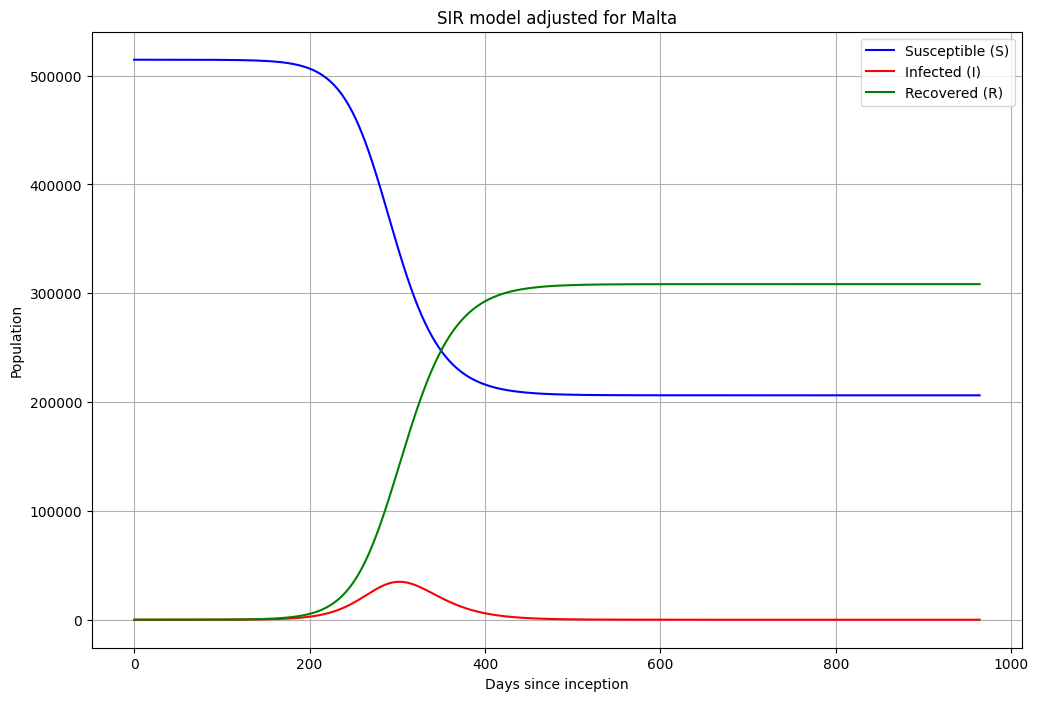

In [99]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Malta'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [100]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Netherlands'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
21092    1.0     0.0     17407585
21091    1.0     0.0     17407585
21090    3.0     0.0     17407585
21089    5.0     0.0     17407585
21088    4.0     0.0     17407585


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Netherlands.png


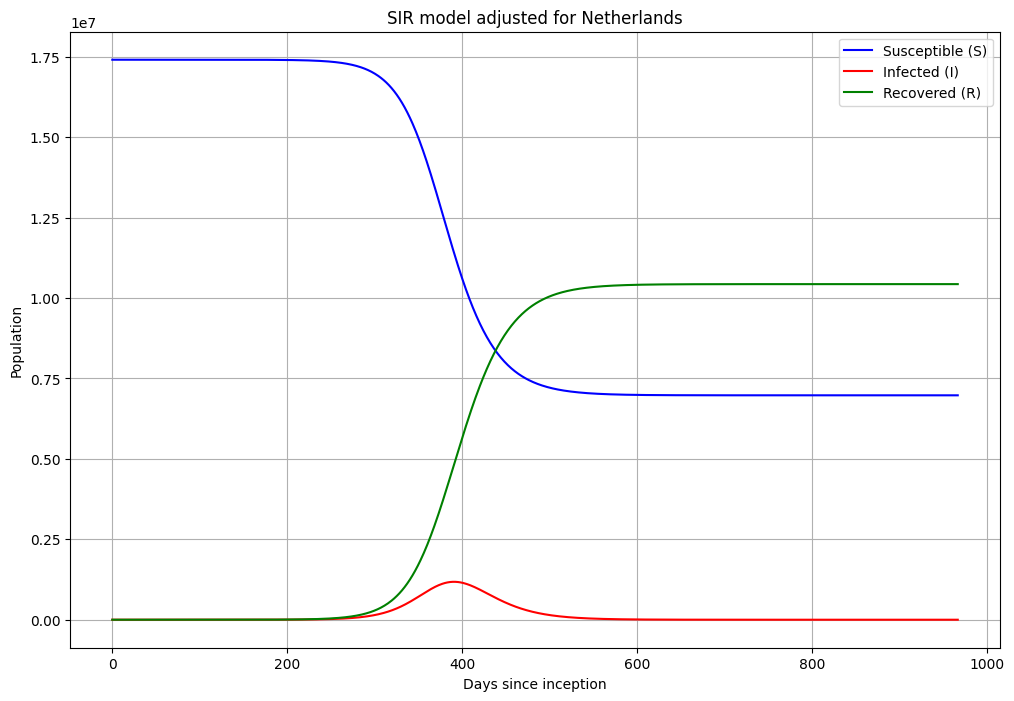

In [101]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Netherlands'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [102]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Poland'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
23038    1.0     0.0     37958138
23037    0.0     0.0     37958138
23036    4.0     0.0     37958138
23035    1.0     0.0     37958138
23034    5.0     0.0     37958138


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Poland.png


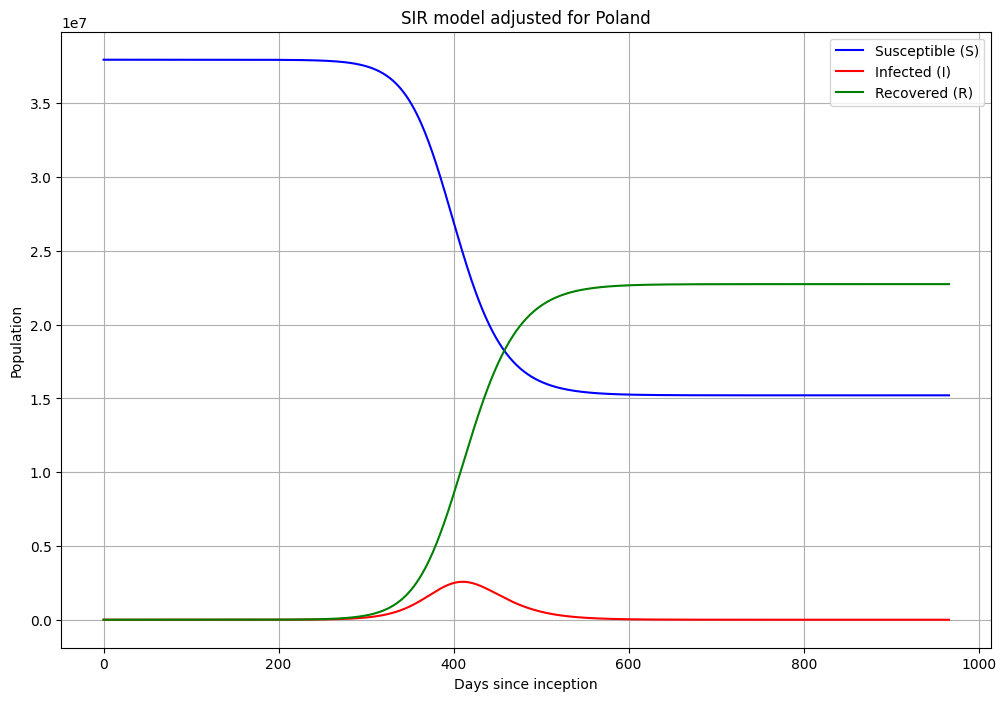

In [104]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Poland'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [127]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Portugal'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
23972    0.0     0.0     10295909
23971    0.0     0.0     10295909
23970    0.0     0.0     10295909
23969    0.0     0.0     10295909
23968    0.0     0.0     10295909


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Portugal.png


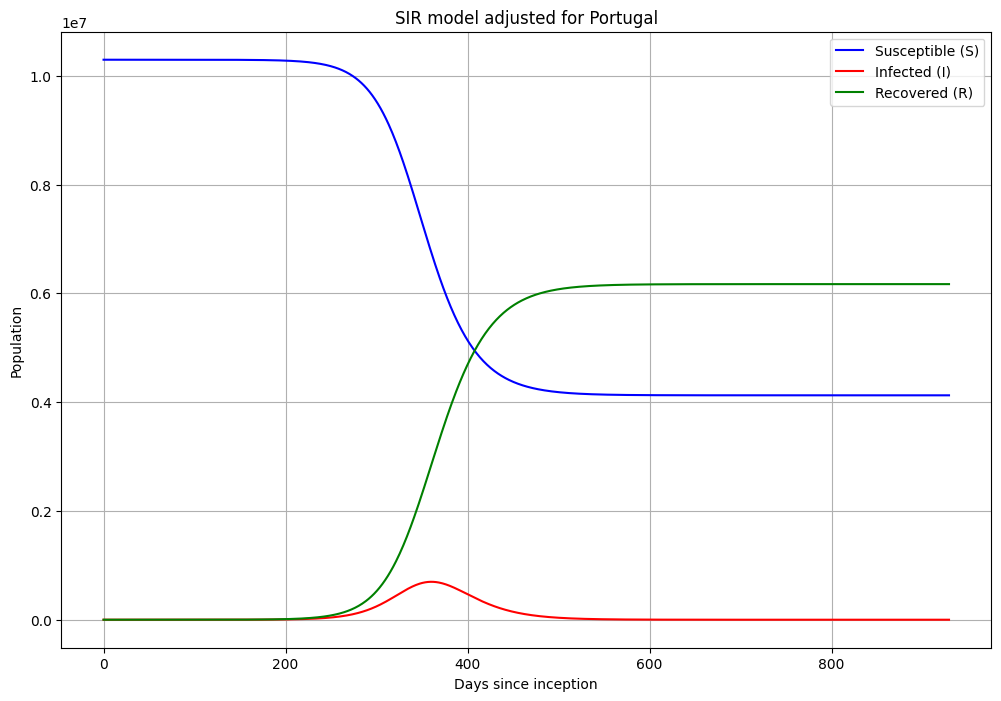

In [105]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Portugal'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Exclude the first row
data_country = data_country.iloc[5:].reset_index(drop=True)

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [106]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Slovakia'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
25850    1.0     0.0      5457873
25849    2.0     0.0      5457873
25848    2.0     0.0      5457873
25847    2.0     0.0      5457873
25846    0.0     0.0      5457873


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Slovakia.png


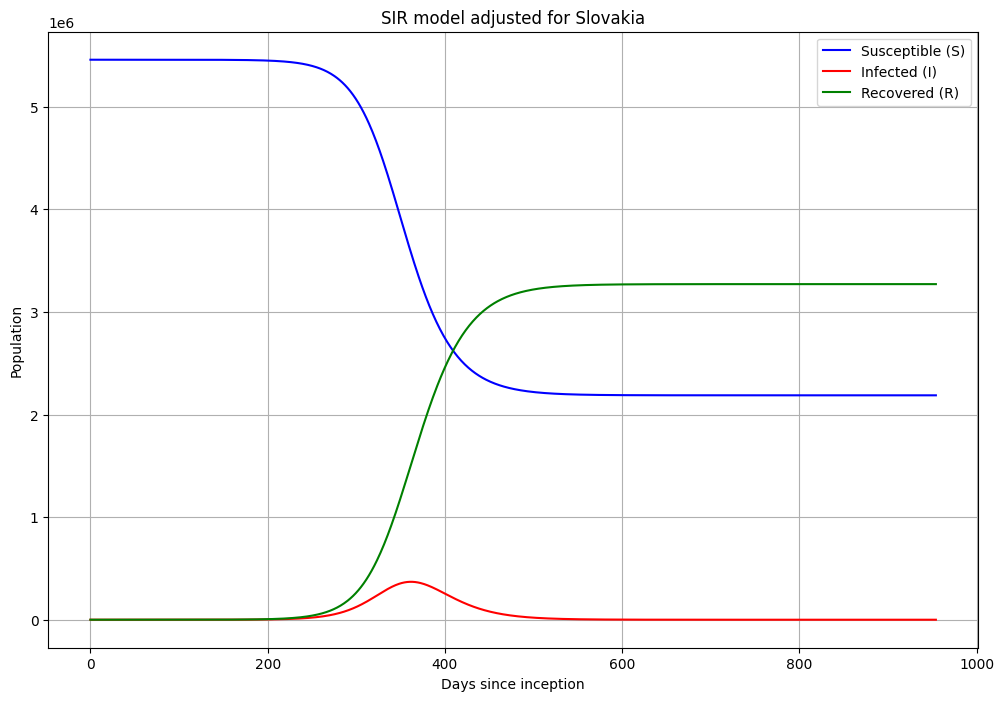

In [107]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Slovakia'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [108]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Spain'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
27746    1.0     0.0     47332614
27745    0.0     0.0     47332614
27744    1.0     0.0     47332614
27743    0.0     0.0     47332614
27742    0.0     0.0     47332614


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Spain.png


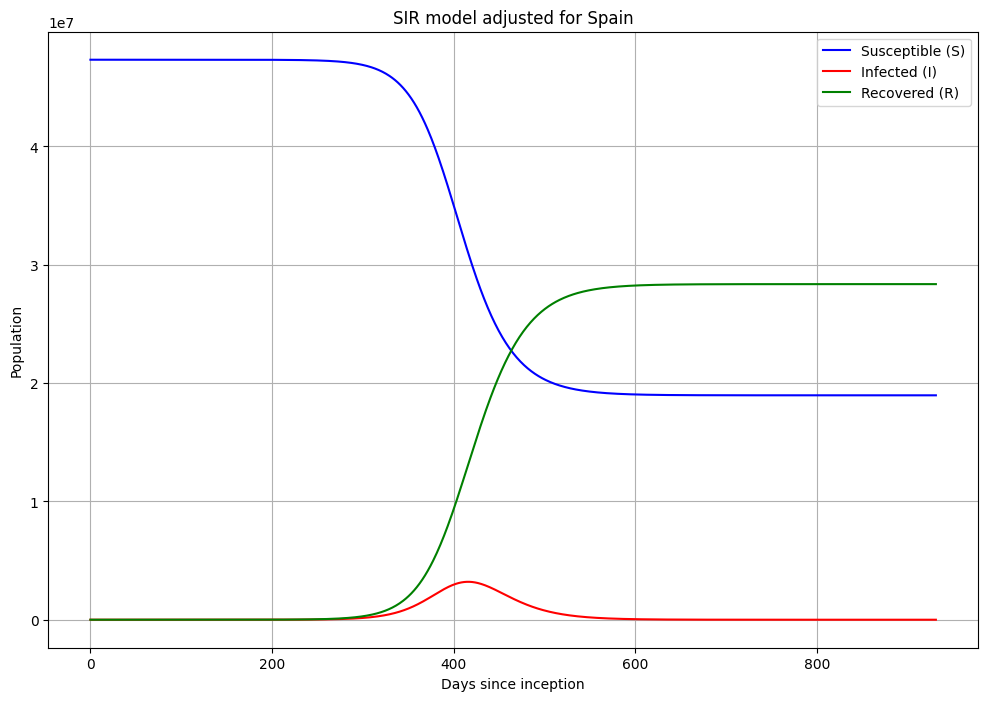

In [109]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Spain'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()


In [110]:
# Detect rows with empty or erroneous values 
print(data[data['countriesAndTerritories'] == 'Sweden'][['cases', 'deaths', 'popData2020']].head())

       cases  deaths  popData2020
28728    1.0     0.0     10327589
28727    0.0     0.0     10327589
28726    0.0     0.0     10327589
28725    0.0     0.0     10327589
28724    0.0     0.0     10327589


Graph saved as: /Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_Sweden.png


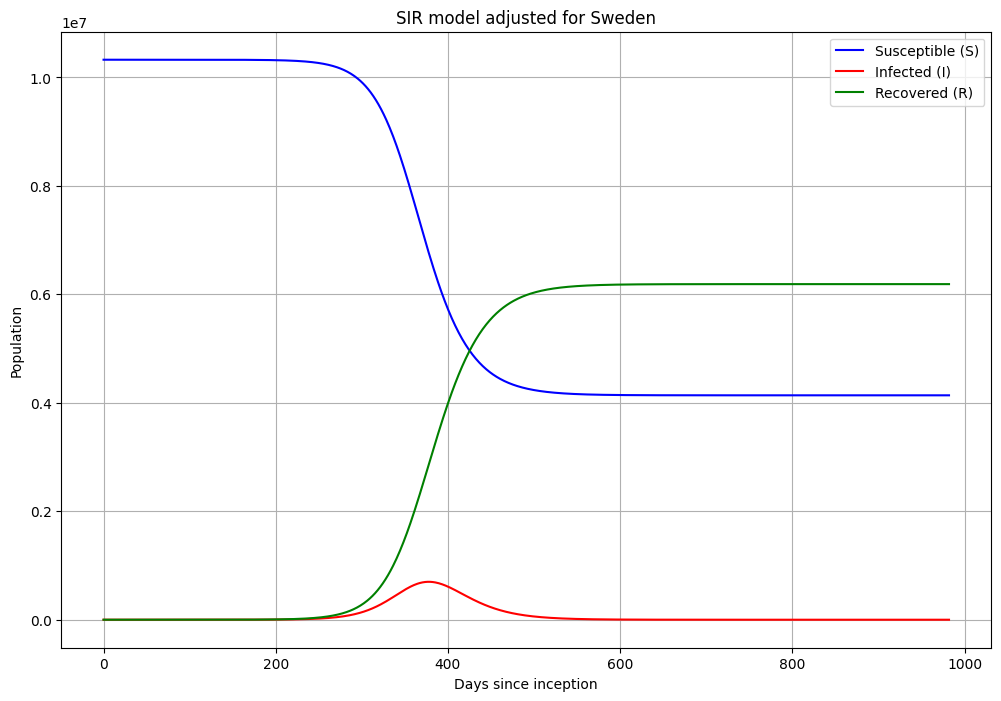

In [111]:
# Loading beta and gamma values from a JSON file
with open('/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/params.json', 'r') as file:
    params = json.load(file)

beta = params['beta']
gamma = params['gamma']

# Data preprocessing
data['dateRep'] = pd.to_datetime(data['dateRep'], format='%d/%m/%Y')
data = data.sort_values(['countriesAndTerritories', 'dateRep'])

# Select a country
country = 'Sweden'
data_country = data[data['countriesAndTerritories'] == country].copy()

# Calculate cumulative cases and deaths
data_country['cum_cases'] = data_country['cases'].cumsum()
data_country['cum_deaths'] = data_country['deaths'].cumsum()

# Assume recovered (14 days after case)
data_country['recovered'] = data_country['cum_cases'].shift(14).fillna(0) - data_country['cum_deaths']

# Calculate active and susceptible infected
N = data_country['popData2020'].iloc[0]
infected_initial = data_country['cum_cases'].iloc[0] - data_country['recovered'].iloc[0]
recovered_initial = data_country['recovered'].iloc[0]
susceptible_initial = N - infected_initial - recovered_initial

# Define the SIR model
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Solving the SIR model
y0 = [susceptible_initial, infected_initial, recovered_initial]
t = np.linspace(0, len(data_country), len(data_country))  # Tiempo en días
solution = odeint(sir_model, y0, t, args=(N, beta, gamma))
S, I, R = solution.T

# Plotting the results
plt.figure(figsize=(12, 8))

# Adjusted SIR model plot
plt.plot(t, S, label='Susceptible (S)', color='blue')
plt.plot(t, I, label='Infected (I)', color='red')
plt.plot(t, R, label='Recovered (R)', color='green')
plt.title(f"SIR model adjusted for {country}")
plt.xlabel('Days since inception')
plt.ylabel('Population')
plt.legend()
plt.grid()

# Save the graph
output_path = f'/Users/Augusto/Desktop/PROYECTOS/SIR MODEL/modelo_SIR_{country}.png'
plt.savefig(output_path, dpi=300)
print(f"Graph saved as: {output_path}")

# Display the graph
plt.show()
